titolo
preparazione dataset

In [65]:

# Import KaggleHub to download the dataset directly from Kaggle
import kagglehub

# Download latest version
path = kagglehub.dataset_download("luisrenterialezano/retail-sales-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Alessia_March\.cache\kagglehub\datasets\luisrenterialezano\retail-sales-dataset\versions\1


In [66]:

# Import the required libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [67]:
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
csv_path = os.path.join(path, csv_files[0])
df = pd.read_csv(csv_path)

# Display the first rows and dataset dimensions
print(df.head())
print(df.shape[0], df.shape[1])

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2  2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4  2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
541909 8


In [68]:

data=df.copy() # working copy of the original dataset

# Remove the product description column since I do not consider it usefull for product segmentation and clustering
data=data.drop(["Description"], axis=1)


In [69]:

data["InvoiceDate"] = pd.to_datetime(
    data["InvoiceDate"]) #convert in datetime

# Identify rows containing at least one missing value
missing_rows = data[data.isna().any(axis=1)]
print(missing_rows.shape[0])
# Check whether all missing values are in CustomerID
missing_customer_id = data[data["CustomerID"].isna()]

# Verify if the two subsets are identical. If this is true then CustomerID is the only column with missing values
same_missing_rows = missing_rows.equals(missing_customer_id)

print(same_missing_rows)

# Removing the rows with missing values. They will be studied afterwards.
validated_data = data[data['CustomerID'].notna()]




135080
True


I filtered the data to retain only transactions with a non-null CustomerID, ensuring customer traceability and the ability to calculate metrics related to the customer base.

In [70]:
country= data["Country"].unique()
country

<StringArray>
[      'United Kingdom',               'France',            'Australia',
          'Netherlands',              'Germany',               'Norway',
                 'EIRE',          'Switzerland',                'Spain',
               'Poland',             'Portugal',                'Italy',
              'Belgium',            'Lithuania',                'Japan',
              'Iceland',      'Channel Islands',              'Denmark',
               'Cyprus',               'Sweden',              'Austria',
               'Israel',              'Finland',              'Bahrain',
               'Greece',            'Hong Kong',            'Singapore',
              'Lebanon', 'United Arab Emirates',         'Saudi Arabia',
       'Czech Republic',               'Canada',          'Unspecified',
               'Brazil',                  'USA',   'European Community',
                'Malta',                  'RSA']
Length: 38, dtype: str

## Creation of the dataset for clustering

In [71]:
# Reference date used to compute product recency
max_date = validated_data["InvoiceDate"].max()

# co-purchase network using only completed purchases
invoice_products = (
    validated_data[validated_data["Quantity"] > 0]
    .groupby("InvoiceNo")["StockCode"]
    .apply(set)
)

co_products = {}

for products in invoice_products:
    for p in products:          # uso p per non sovrascrivere product
        if p not in co_products:
            co_products[p] = set()

        co_products[p].update(products - {p})

num_distinct_coproducts = {
    p: len(others)
    for p, others in co_products.items()
}# all distinct products that co-occur with each product across purchase transactions

# List that will store aggregated product-level features
final_rows = []

# Group dataset by product 
product_groups = validated_data.groupby("StockCode")

for product, product_data in product_groups:

    product_data = product_data.copy()

    # Separate purchases and returns
    purchases = product_data[product_data["Quantity"] > 0].copy()
    returns = product_data[product_data["Quantity"] < 0].copy()

    # Skip products with no valid purchases
    if len(purchases) == 0:
        continue

    # Compute transaction value
    purchases["TotalValue"] = (
        purchases["Quantity"] * purchases["UnitPrice"]
    )

    returns["TotalValue"] = (
        abs(returns["Quantity"]) * returns["UnitPrice"]
    )

    # Total quantities
    total_quantity_purchased = purchases["Quantity"].sum()
    total_quantity_returned = abs(returns["Quantity"].sum())

    # Number of unique orders containing the product
    num_orders = purchases["InvoiceNo"].nunique()

    # Return ratio
    total_quantity = total_quantity_purchased + total_quantity_returned

    return_ratio = (
        total_quantity_returned / total_quantity
        if total_quantity > 0
        else 0
    )

    # Number of unique customers purchasing the product
    num_unique_customers = purchases["CustomerID"].nunique()

    # Order timestamps sorted chronologically
    order_dates = (
        purchases.groupby("InvoiceNo")["InvoiceDate"]
        .min()
        .sort_values()
    )

    # Median time between consecutive purchases (in hours)
    if len(order_dates) > 1:
        time_diffs = order_dates.diff().dropna()
        median_time_between_orders = (
            time_diffs.median().total_seconds() / 3600
        )
    else:
        median_time_between_orders = 0

    # Recency: days since last purchase
    last_purchase_date = purchases["InvoiceDate"].max()
    recency_days = (max_date - last_purchase_date).days

    # Total revenue generated by the product
    total_revenue = purchases["TotalValue"].sum()

    # Country entropy (geographical dispersion of demand)
    country_counts = (
        purchases.groupby("Country")["CustomerID"]
        .nunique()
    )

    if len(country_counts) <= 1:
        country_entropy = 0
    else:
        country_proportions = (
            country_counts / country_counts.sum()
        )

        entropy = (
            -country_proportions * np.log(country_proportions)
        ).sum()

        country_entropy = entropy / np.log(len(country_counts))

    # Co-purchase ratio: diversity of products bought together,
    # normalized by the number of orders containing the product
    num_distinct_coproducts_ratio = (
        num_distinct_coproducts.get(product, 0) / num_orders
        if num_orders > 0 else 0
    )
    
    # Store features 
    final_rows.append({
        "StockCode": product,

        "country_entropy": country_entropy,
        "total_quantity_purchased": total_quantity_purchased,
        "total_quantity_returned": total_quantity_returned,
        "num_distinct_coproducts_ratio": num_distinct_coproducts_ratio,
        "num_orders": num_orders,
        "return_ratio": return_ratio,
        "median_time_between_orders": median_time_between_orders,
        "num_unique_customers": num_unique_customers,
        "recency_days": recency_days,
        "total_revenue": total_revenue
    })

# Final dataset for product clustering
product_features = pd.DataFrame(final_rows)

product_features.head()

,StockCode,country_entropy,total_quantity_purchased,total_quantity_returned,num_distinct_coproducts_ratio,num_orders,return_ratio,median_time_between_orders,num_unique_customers,recency_days,total_revenue
0,10002,0.481421,823,0,21.306122,49,0.0,47.508333,40,234,699.55
1,10080,0.000000,291,0,28.809524,21,0.0,192.691667,19,17,114.41
2,10120,0.242292,193,0,34.517241,29,0.0,142.833333,25,4,40.53
3,10123C,0.000000,5,0,28.333333,3,0.0,1416.958333,3,252,3.25
4,10124A,0.000000,16,0,39.200000,5,0.0,1215.541667,5,32,6.72



The goal of this phase was to construct a dataset of product-level features that could be used to segment products into homogeneous groups.

## Features Constructed for Each Product
For each product identified by its StockCode, I constructed a set of ten features describing various aspects of its sales behavior:

- **total_quantity_purchased**: total quantity of the product purchased.

- **total_quantity_returned**: total quantity returned.

- **total_revenue**: total revenue generated by the product, calculated as the sum of quantity times unit price across all purchase transactions.

- **num_orders**: number of unique orders containing the product.

- **num_unique_customers**: number of unique customers who purchased the product.

- **recency_days**: days elapsed since the product's last purchase, calculated relative to the latest date in the dataset.

- **median_time_between_orders**: median time (in hours) between consecutive purchases of the product.

- **return_ratio**: ratio of returned quantity to total quantity.

- **country_entropy**: normalized entropy of the geographic demand distribution, measuring the product's international reach; values ​​close to zero indicate sales concentrated in a single country, while values ​​close to one indicate uniform distribution across countries.

- **num_distinct_coproducts_ratio**: ratio of the number of distinct products purchased alongside this product to the number of orders containing it; high values ​​indicate it is frequently purchased with many different products, while low values ​​indicate it is purchased alone or consistently with the same products.


## Correlation Matrix Analysis

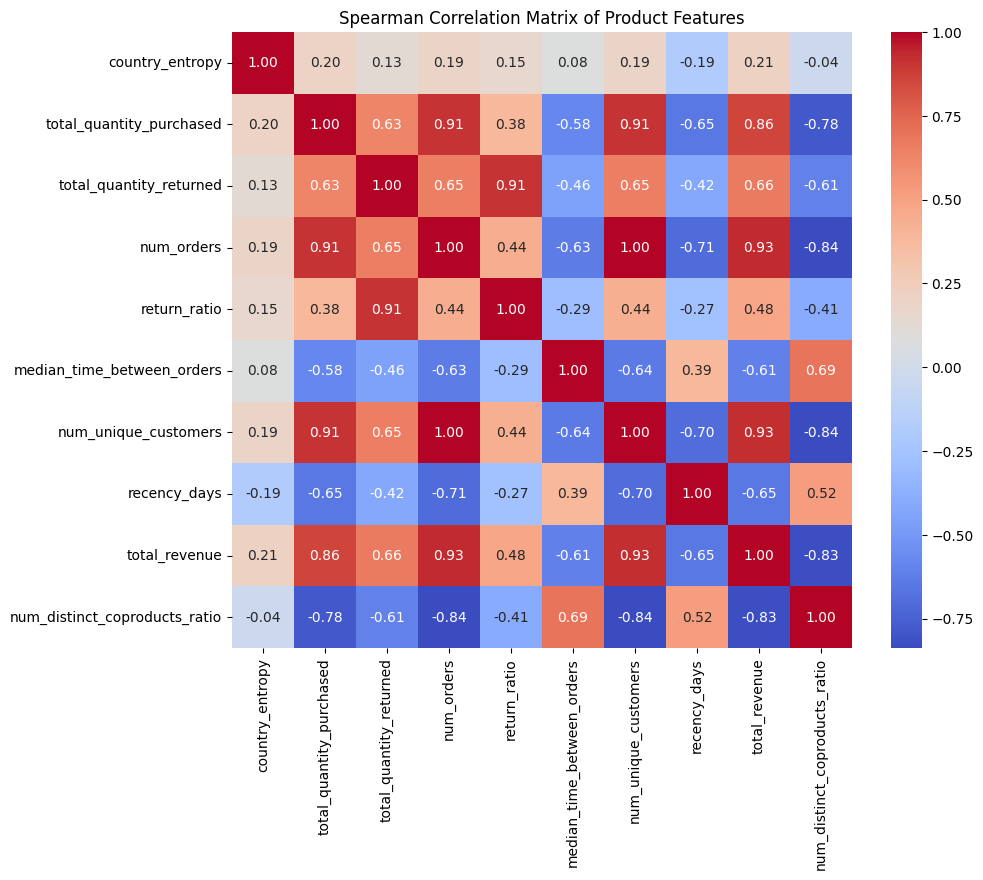

In [72]:
# Features selected for correlation analysis
feature_cols = [
    'country_entropy',
    'total_quantity_purchased',
    "total_quantity_returned",
    'num_orders',
    'return_ratio',
    'median_time_between_orders',
    'num_unique_customers',
    'recency_days',
    'total_revenue',
    "num_distinct_coproducts_ratio"
]

# Compute the Spearman correlation matrix.
# Spearman correlation is preferred because several features are highly skewed and may not have a linear relationship.
corr_matrix = product_features[feature_cols].corr(
    method='spearman'
)

# Visualize the correlation matrix
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Spearman Correlation Matrix of Product Features")
plt.show()


The Spearman correlation matrix reveals significant relationships between the variables. The strongest correlations indicate redundancies that should be eliminated:

**Obvious redundancies**:
- **num_orders** and **num_unique_customers** are almost perfectly correlated (0.99): products purchased across many orders inevitably have a broad customer base.
- **total_revenue** is strongly correlated with **num_orders** (0.93) and **num_unique_customers** (0.93): the highest-value products are also the most widely distributed.
- **total_revenue** and **total_quantity_purchased** show a correlation of 0.86, given that revenue is derived from quantity multiplied by price.

**Significant negative correlations**:
- **num_distinct_coproducts_ratio** is negatively correlated with **num_orders** (-0.84) and **total_revenue** (-0.83): best-selling products tend to be purchased alongside a smaller variety of other products, likely because they are mass-market items purchased more independently.
- **recency_days** is negatively correlated with **total_revenue** (-0.65) and **num_orders** (-0.71): products with more recent sales are the most commercially successful.

**Correlations with return rate**:
- **return_ratio** is strongly correlated with **total_quantity_returned** (0.91).

To reduce redundancy among the features and improve the interpretability of the resulting clusters, only the following variables will be retained: **country_entropy**, **return_ratio**, **median_time_between_orders**, **recency_days**, and **total_revenue**.


## Data Normalization and Transformation for GMM

In [73]:
features_rfm =['country_entropy',
'return_ratio',
'median_time_between_orders',
'recency_days',
'total_revenue'
]

# Calculate and print skewness of the selected features
# Skewness indicates whether data is symmetrically distributed or has long tails
print(product_features[features_rfm].skew())

country_entropy                0.905998
return_ratio                   5.366741
median_time_between_orders     5.500002
recency_days                   2.092836
total_revenue                 11.244759
dtype: float64


The data do not follow a normal distribution; indeed, they exhibit long right-hand tails, particularly for 'total_revenue', 'return_ratio', and 'median_time_between_orders', which isn't great for a Gaussian model like GMM because it assumes the data are generated by a mixture of Gaussian distributions.

First, I apply a RobustScaler at the raw data – mainly because it's based on median and IQR, so it handles outliers way better than StandardScaler would. Then I used MCD to flag and filter out the most extreme customer cases (I will analyze them separately at the end). After that, I applied some transformations to handle the skewness: natural logarithm for 'total_revenue', 'median_time_between_orders', and 'recency_days', and the square root for 'return_ratio'. I re-apply RobustScaler in order to have every variable on the same scale.


In [74]:
from sklearn.preprocessing import RobustScaler # RobustScaler uses median and IQR, making it robust to outliers


scaler = RobustScaler()

scaled_data = scaler.fit_transform(product_features[features_rfm])

## Initial PCA Visualization

[0.36379687 0.32016926] 0.6839661209377195


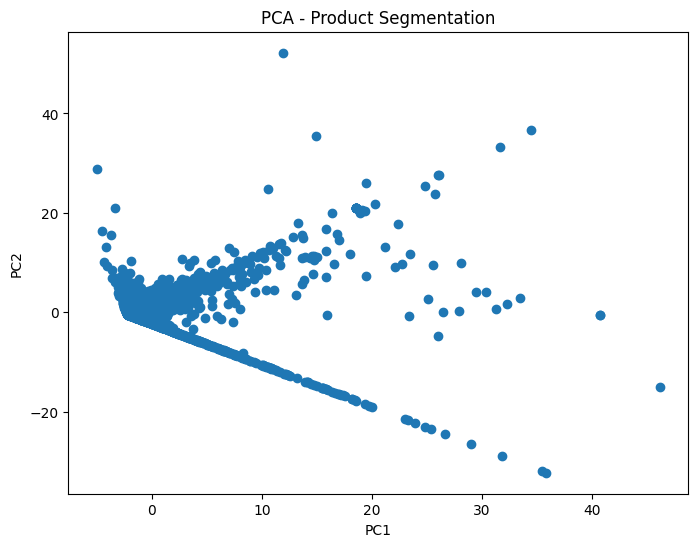

In [75]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)# Initialize PCA with 2 components for 2D visualization

X_transformed = pca.fit_transform(scaled_data)

print(pca.explained_variance_ratio_,sum(pca.explained_variance_ratio_))# This shows how much variance is captured by each PC and cumulatively

# Create a figure for the PCA scatter plot
plt.figure(figsize=(8,6))

plt.scatter(
    X_transformed[:, 0],
    X_transformed[:, 1]
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA - Product Segmentation")

plt.show()


I used PCA to visualize the data, even though the first two components explain only 67% of the variance, that is sufficient for a preliminary visualization, as it will not be used for the actual clustering.

Following the initial scaling with RobustScaler, the plot reveals the presence of outliers, highlighted as isolated points far from the main body of the distribution. These extreme data points—characterized by anomalous values ​​in one or more dimensions—could skew the clustering analysis.

## Outliers detection 

In [76]:
from sklearn.covariance import MinCovDet
# Detection of outliers by estimating a robust covariance matrix
mcd = MinCovDet(random_state=42)
mcd.fit(scaled_data)

,"store_precision store_precision: bool, default=TrueSpecify if the estimated precision is stored.",True
,"assume_centered assume_centered: bool, default=FalseIf True, the support of the robust location and the covarianceestimates is computed, and a covariance estimate is recomputed fromit, without centering the data.Useful to work with data whose mean is significantly equal tozero but is not exactly zero.If False, the robust location and covariance are directly computedwith the FastMCD algorithm without additional treatment.",False
,"support_fraction support_fraction: float, default=NoneThe proportion of points to be included in the support of the rawMCD estimate. Default is None, which implies that the minimumvalue of support_fraction will be used within the algorithm:`(n_samples + n_features + 1) / 2 * n_samples`. The parameter must bein the range (0, 1].",None
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines the pseudo random number generator for shuffling the data.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


In [77]:

# Calculate the Mahalanobis distance for each data point
# It measures how many standard deviations away a point is from the distribution
# It's more robust than Euclidean distance as it accounts for feature correlations

dist = mcd.mahalanobis(scaled_data)

In [78]:

# Set a threshold at the 95th percentile of the Mahalanobis distances
# Points beyond this threshold are considered outliers (top 5% most extreme points)
threshold = np.percentile(dist, 95)

In [79]:
# Create a boolean mask identifying outliers
outliers = dist > threshold 

print("Outliers:", outliers.sum()) # n° of outliers
print("percentage:", outliers.mean() * 100) # % outliers

Outliers: 184
percentage: 5.020463847203274


In [80]:
df_no_outlier = product_features.loc[~outliers].copy() #data without outliers

## check of the Skewness After Outlier Removal

In [81]:
# Calculate and print skewness of the selected features
# Skewness indicates whether data is symmetrically distributed or has long tails
print(df_no_outlier[features_rfm].skew())

country_entropy                0.858001
return_ratio                   4.961091
median_time_between_orders     4.391770
recency_days                   2.221911
total_revenue                 11.017275
dtype: float64



Following the removal of outliers identified via Mahalanobis distance, the skewness of the variables did not improve significantly. This residual skewness necessitates further transformations to make the data closer to the assumptions underlying Gaussian mixture models.

## Transformations to Reduce Skewness

In [82]:
df_clean = df_no_outlier.copy()
cols_log = [
    "total_revenue",
    'median_time_between_orders',        
    'recency_days'

]# List of columns to transform with natural logarithm (to reduce skewness), that could cause issues with GMM

for col in cols_log:
    df_clean[col] = np.log1p(df_clean[col])
    
df_clean["return_ratio"] = np.sqrt(df_clean["return_ratio"])

print(df_clean[features_rfm].skew())


country_entropy               0.858001
return_ratio                  2.193420
median_time_between_orders   -0.067290
recency_days                  0.668558
total_revenue                -0.349718
dtype: float64


After removing outliers, I applied `log1p` to `total_revenue`, `median_time_between_orders`, and `recency_days`, and `sqrt` to `return_ratio`.

The transformed variables now exhibit skewness values ​​close to zero—or at least well within acceptable limits—making the data much more suitable for the Gaussian Mixture Model.  `return_ratio`, however, remains highly skewed (2.19) due to the high concentration of zero values ​​(customers with no returns), though the `sqrt` transformation improved the situation compared to the initial skewness of 4.96.

## PCA After Outlier Removal and Transformations

[0.38125216 0.2743165 ] 0.6555686622047315


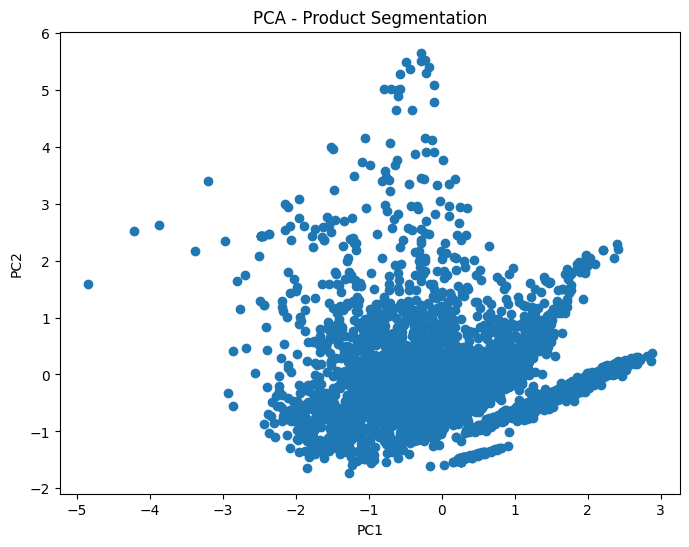

In [83]:
X_clean = df_clean[features_rfm].copy()


scaler_final = RobustScaler()
#scaler_final = StandardScaler()

X_clean_scaled = scaler_final.fit_transform(X_clean)


#new pca plot without outliers
pca_clean = PCA(n_components=2)

pca_df_clean = pca_clean.fit_transform(X_clean_scaled)

print(pca_clean.explained_variance_ratio_,sum(pca_clean.explained_variance_ratio_))

plt.figure(figsize=(8,6))

plt.scatter(
    pca_df_clean[:, 0],
    pca_df_clean[:, 1]
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA - Product Segmentation")

plt.show()


After removing outliers and applying transformations to reduce skewness, I used again PCA to visualize the products in a two dimensional space. Compared with the initial PCA projection, the observations are now more concentrated around the center and the isolated extreme points have disappeared.

## Correlation Matrix After Transformations

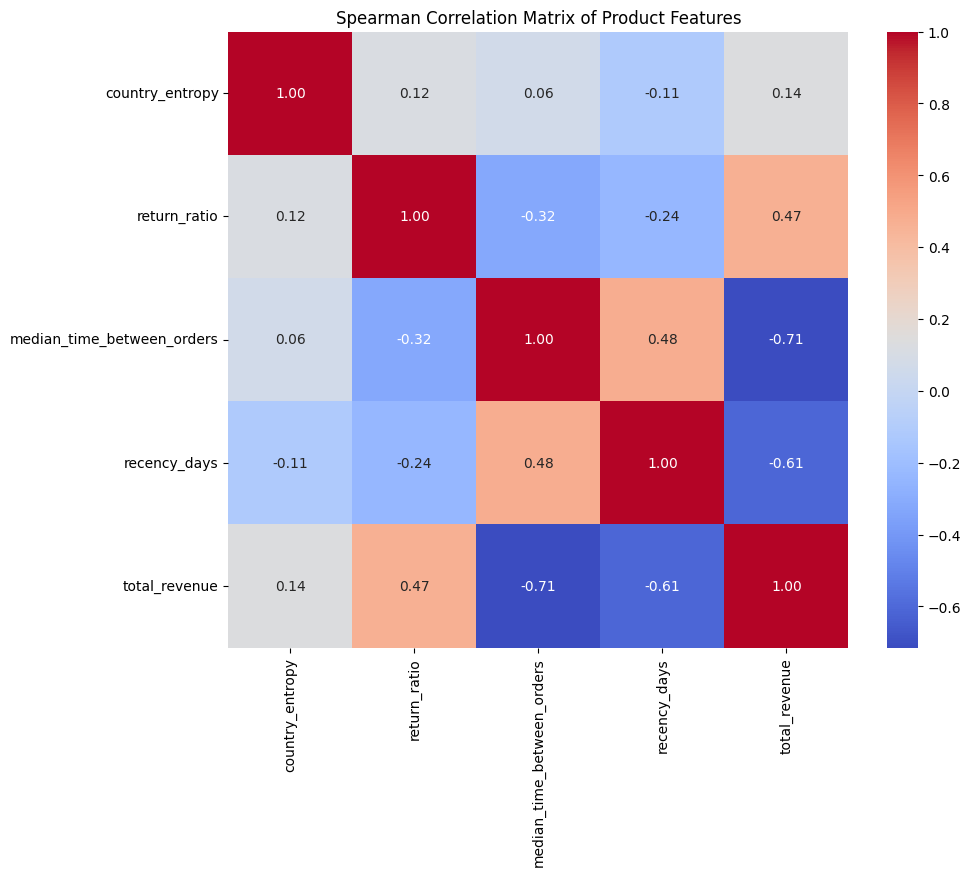

In [84]:

# Calculate the Spearman correlation matrix between the selected features. Using Spearman, the output is not influenced by the logarithm transformation

corr_matrix = df_no_outlier[features_rfm].corr(method='spearman')

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Spearman Correlation Matrix of Product Features")
plt.show()


I re-used the Spearman correlation matrix in order to better understand the relationships between the remaining variables:
- **total_revenue** is negatively correlated with **median_time_between_orders** (-0.71): products generating higher revenue tend to be purchased more frequently.
- **total_revenue** is negatively correlated with **recency_days** (-0.61): more recent products generate higher revenue.
- **recency_days** is positively correlated with **median_time_between_orders** (0.48): products with less recent purchases tend to have longer intervals between purchases.
- **total_revenue** is positively correlated with **return_ratio** (0.47): top-selling products tend to have higher return rates.

The remaining correlations are weak or negligible. Although some variables show moderate correlations, they were retained because they capture distinct aspects of product behavior: for instance, **median_time_between_orders** and **recency_days**, while correlated, measure purchase regularity and recency respectively that are two different temporal dimensions that enrich the product profile.

# Why I chose the Gaussian Mixture Model (GMM)


GMM assigns each product to a cluster based on **probability**, rather than categorically. That's useful for spotting hybrid products, but in our data, the average assignment confidence turned out to be around 0.94. It also allows to identifying products on the boundary between clusters.

**Flexibility in cluster shape** is another advantage – GMM handles elliptical shapes and correlations between variables, which K-means can't do.
It's also based on maximum likelihood estimation and the EM algorithm. I used BIC to select the optimal number of clusters (8), balancing fit and complexity.

Despite all of that, GMM assumes Gaussian distributions, so I had to transform the data (log and square root) and remove outliers first. Too many clusters can also lead to overfitting, but BIC helped avoid that.


## Selecting the Optimal Number of Clusters Using BIC

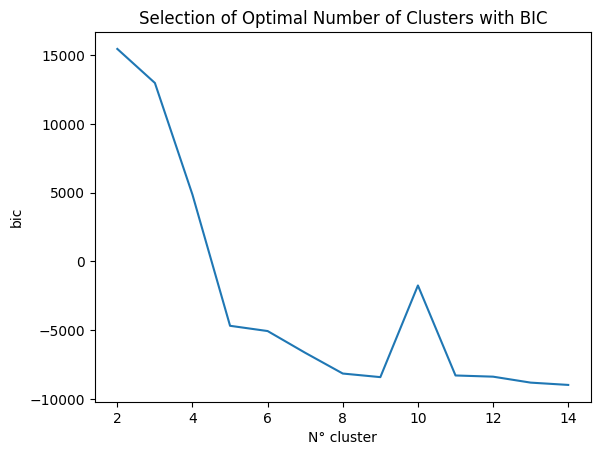

In [86]:
# Import GaussianMixture for model-based clustering
# GMM assumes data is generated from a mixture of Gaussian distributions
from sklearn.mixture import GaussianMixture

bic=[]# BIC is used for model selection - lower values indicate better models

# Define the range of number of components (clusters) to test
n_components_range=range(2,15)


for n in n_components_range:
    # Initialize Gaussian Mixture Model with n components
    gmm = GaussianMixture( n_components=n, random_state=42)
    # Fit the GMM to the scaled clean data
    gmm.fit(X_clean_scaled)
    # Calculate and store the BIC score for this model
    # BIC penalizes model complexity, helping to avoid overfitting
    bic.append(gmm.bic(X_clean_scaled))

# Create a line plot of BIC values vs number of components
plt.plot(n_components_range, bic)
plt.xlabel("N° cluster")
plt.ylabel("bic")
plt.title("Selection of Optimal Number of Clusters with BIC")
plt.show()


In [87]:
best_n = n_components_range[np.argmin(bic)]
print("Numero ottimale cluster:", best_n)

Numero ottimale cluster: 14



To determine the optimal number of clusters, I choose the Bayesian Information Criterion (BIC), which it rewards models that fit the data well, but penalizes them if they get too complicated by using too many parameters.

Although the minimum BIC was obtained with 14 components, the reduction after eight clusters became relatively small while the interpretability decreased substantially. I chose eight clusters as a compromise between statistical fit and practical interpretability.

## Assessment of Cluster Assignment Confidence

count    3481.000000
mean        0.951681
std         0.106550
min         0.471809
25%         0.969570
50%         0.999779
75%         0.999973
max         1.000000
dtype: float64


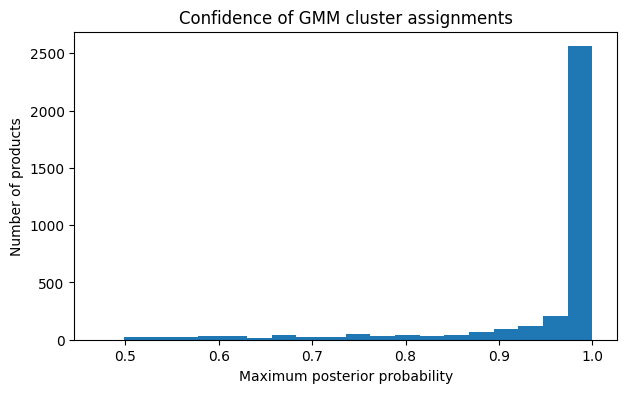

Products with P > 0.99 : 68.9%
Products with P > 0.95 : 79.1%
Products with P > 0.90 : 85.0%
Products with P < 0.70 : 6.1%


In [ ]:
# Initialize Gaussian Mixture Model with 8 clusters
gmm = GaussianMixture(
    n_components=8 ,
    random_state=42
)
# Fit the GMM to the scaled clean data and predict cluster labels
labels = gmm.fit_predict(X_clean_scaled)

# Posterior probabilities
probs = gmm.predict_proba(X_clean_scaled)

# Highest probability for each observation
max_probs = probs.max(axis=1)

print(pd.Series(max_probs).describe())

plt.figure(figsize=(7,4))

plt.hist(max_probs, bins=20)

plt.xlabel("Maximum posterior probability")
plt.ylabel("Number of products")
plt.title("Confidence of GMM cluster assignments")

plt.show()


print(f"Products with P > 0.99 : {(max_probs > 0.99).mean()*100:.1f}%")
print(f"Products with P > 0.95 : {(max_probs > 0.95).mean()*100:.1f}%")
print(f"Products with P > 0.90 : {(max_probs > 0.90).mean()*100:.1f}%")
print(f"Products with P < 0.70 : {(max_probs < 0.70).mean()*100:.1f}%")


To evaluate the reliability of the cluster assignments, I examined the maximum posterior probabilities for each product: the majority of products are assigned to clusters with high confidence: 68.9% of products have a maximum probability exceeding 0.99, 79.1% exceeding 0.95, and 85.0% exceeding 0.90. The average maximum probability is 0.95, with a standard deviation of 0.11.

Only 6.1% of products exhibit a maximum probability below 0.70, indicating that few products lie in boundary areas between different clusters. These results confirm that the GMM model with 8 clusters has identified well-separated and distinct groups.

## Cluster Visualization
## PCA Projection

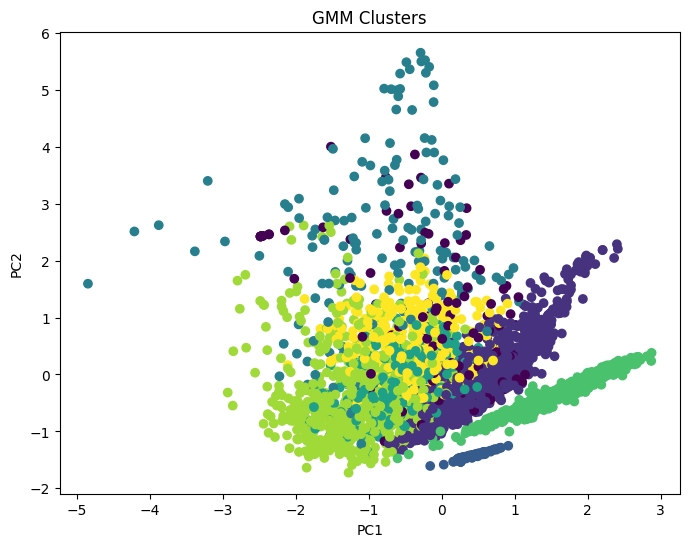

In [89]:
# Plot pca, colored by cluster assignment

plt.figure(figsize=(8,6))

plt.scatter(
    pca_df_clean[:,0],
    pca_df_clean[:,1],
    c=labels
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("GMM Clusters")

plt.show()


The PCA projection of the data, colored according to cluster assignments, reveals an overall well-defined structure, although some overlap between adjacent clusters is observed. This overlap is inherent to a probabilistic model like GMM, where clusters are represented by Gaussian distributions that can intersect in certain boundary areas—as seen with the yellow and green clusters. Nevertheless, many points are clearly attributable to specific clusters (specifically, the three clusters in the bottom-right area).

### Distribution Pairplot

Clusters with zero-return customers: [1 5 2 6]


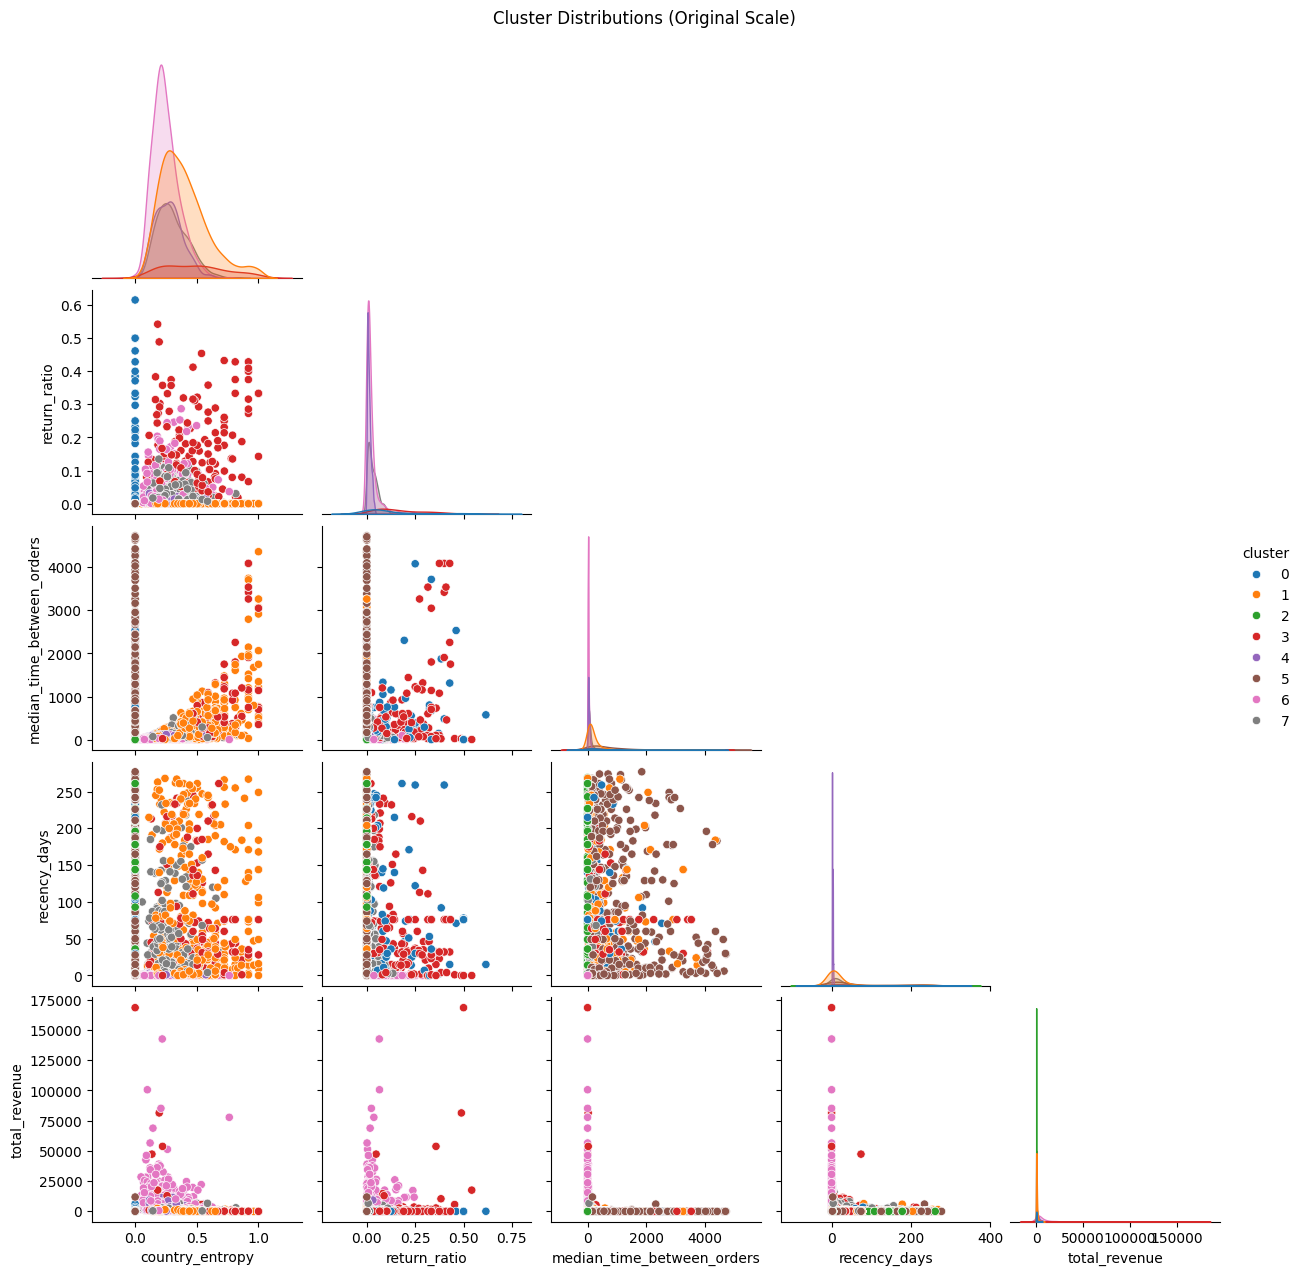

In [90]:
# Create dataframe with ORIGINAL (back-transformed) values and cluster assignments
# back-transform log-transformed values to original scale
df_backtransformed = df_clean.copy()
for col in ["total_revenue",
    'median_time_between_orders',        
    'recency_days']:
    df_backtransformed[col] = np.expm1(df_backtransformed[col])

df_backtransformed["return_ratio"]=df_backtransformed["return_ratio"]**2

df_backtransformed["cluster"] = labels

# Check if any cluster consists only of customers with zero returns
print("Clusters with zero-return customers:", 
      df_backtransformed[df_backtransformed["return_ratio"] == 0]["cluster"].unique())

# pairplot with original scale values
sns.pairplot(
    df_backtransformed,
    vars=features_rfm,  # These are now in original scale
    hue="cluster",
    palette="tab10",
    corner=True
)
plt.suptitle("Cluster Distributions (Original Scale)", y=1.02)
plt.show()





The pairplot of the variables on their original scales confirms the observations from the PCA plot. The separation is particularly distinct for certain pairs of variables—such as `total_revenue` and `country_entropy` or `total_revenue` and `return_ratio`—where the clusters occupy clearly differentiated regions, especially at values ​​close to zero. However, some overlap is evident in specific areas of the plot, particularly regarding variables like `median_time_between_orders` and `recency_days`, where the clusters exhibit closer distributions. Nevertheless, this overlap is limited and does not compromise the overall interpretability of the identified segments.

## Cluster Profile Analysis

In [91]:
cluster_sizes = df_backtransformed.groupby("cluster").size().rename("cluster_size")

# median values for all features
cluster_medians = df_backtransformed.groupby("cluster")[features_rfm].median().round(2)

# mean values for all features
clusters_mean= df_backtransformed.groupby("cluster")[features_rfm].mean().round(2)

original_clusters_median = pd.concat([cluster_sizes, cluster_medians], axis=1)

print("\nCluster profiles (median values - original scale):")
print(original_clusters_median)

original_clusters_mean = pd.concat([cluster_sizes, clusters_mean], axis=1)

print("\nCluster profiles (mean values - original scale):")
print(original_clusters_mean)


Cluster profiles (median values - original scale):
         cluster_size  country_entropy  return_ratio  \
cluster                                                
0                 121             0.00          0.06   
1                 930             0.36          0.00   
2                  79             0.00          0.00   
3                 158             0.47          0.14   
4                 389             0.27          0.01   
5                 539             0.00          0.00   
6                 865             0.23          0.01   
7                 400             0.28          0.02   

         median_time_between_orders  recency_days  total_revenue  
cluster                                                           
0                            193.12          36.0         157.50  
1                             98.18           3.0         383.13  
2                              0.00         151.0           8.95  
3                            168.22          32.0   

The eight clusters can be interpreted as follows:

### High-performing products (Clusters 4, 6, and 7)
These three clusters contain the best-selling products. They are characterized by high revenue, recent sales, and relatively short intervals between purchases, indicating strong and consistent demand. Cluster 6 represents the top-performing products, while Clusters 4 and 7 include products with slightly lower—but still strong—commercial performance.

### Standard products (Cluster 1)
This is the largest cluster and represents the core of the product portfolio. Products have no returns, average revenue, recent sales, and a relatively broad geographic reach, suggesting stable demand and reliable commercial performance.

### Low-performing products (Clusters 2 and 5)
Both clusters contain products with limited commercial success. They generate low revenue, are sold in few markets, and are purchased infrequently. Cluster 2 includes products that are almost inactive, often appearing in only one purchase, whereas Cluster 5 contains slow-moving products that are still sold occasionally.

### Niche products (Cluster 0)
Products in this cluster are sold almost exclusively in one country and have long intervals between purchases. Their moderate revenue and sporadic sales suggest seasonal or niche products serving a limited market.

### International products with higher returns (Cluster 3)
This cluster stands out because of its wide geographic distribution and the highest return rate among all clusters. Although revenue is average, the relatively high return ratio suggests that these products deserve further investigation.

### Summary
Overall, the segmentation reveals a clear hierarchy ranging from low-performing products to the company's top sellers. Revenue, purchase frequency, geographic reach, and return behaviour are the main factors distinguishing the different groups.

### Strategic Implications
- **Clusters 4, 6, and 7:** maintain availability and continue investing in products with strong commercial performance.
- **Cluster 3:** investigate the causes of the higher return rate to identify possible quality or customer satisfaction issues.
- **Clusters 2 and 5:** review the product portfolio and evaluate promotional actions or possible discontinuation for the weakest products.
- **Cluster 0:** monitor demand and manage inventory carefully, as these products appear to serve niche or seasonal markets.

## Outlier Analysis

In [92]:
# Create a DataFrame with only outlier rows for analysis
df_outliers = product_features[outliers].copy()
df_outliers['distanza_mahalanobis'] = dist[outliers]



# 1. HOW MANY OUTLIERS ARE THERE?
print(f"Outlier: {outliers.sum()} over {len(product_features)} products ({outliers.mean()*100:.1f}%)")

# 2. WHAT MAKES THEM DIFFERENT? (compare medians)
print("\n" + "="*50)
print("COMPARISON (median)")
print("="*50)

#compare normal vs outlier
for col in features_rfm:

    normale = product_features.loc[~outliers, col].median()

    outlier_val = df_outliers[col].median()
    
    # Categorize outliers based on how different they are
    if outlier_val > normale * 2:
        
        print(f"{col}: HIGHER OUTLIER ({outlier_val:.1f} vs {normale:.1f})")# Outliers have values more than double the normal median
    elif outlier_val < normale / 2:
        
        print(f"{col}: LOWER OUTLIER ({outlier_val:.1f} vs {normale:.1f})")# Outliers have values less than half the normal median
    else:
        
        print(f"{col}: similar ({outlier_val:.1f} vs {normale:.1f})")# Outliers are relatively similar to normal customers

print("\n" + "="*50)
print("TYPES OF OUTLIERS")
print("="*50)

# Count high-spending outliers (top 5% of spending)
print(f" products with spending > 95th percentile: {(df_outliers['total_revenue'] > product_features['total_revenue'].quantile(0.95)).sum()}")

# Count products with high return ratio (>50%)
print(f" products with many returns (>50%): {(df_outliers['return_ratio'] > 0.5).sum()}")

# Count of products with >1 year since last purchase
print(f" product with >1 year last purchase: {(df_outliers['recency_days'] > 365).sum()}")

# Count products in only 1 order (single purchase)
print(f" products in only 1 order: {(df_outliers['num_orders'] == 1).sum()}")

Outlier: 184 over 3665 products (5.0%)

COMPARISON (median)
country_entropy: LOWER OUTLIER (0.0 vs 0.2)
return_ratio: LOWER OUTLIER (0.0 vs 0.0)
median_time_between_orders: similar (27.8 vs 52.7)
recency_days: HIGHER OUTLIER (317.0 vs 3.0)
total_revenue: LOWER OUTLIER (19.4 vs 698.2)

TYPES OF OUTLIERS
 products with spending > 95th percentile: 0
 products with many returns (>50%): 6
 product with >1 year last purchase: 31
 products in only 1 order: 75


A total of **184 outlier products** were identified, corresponding to about **5% of the dataset**. Compared with the remaining products, they are generally older, generate much lower revenue, and are typically sold in only one country. By contrast, `return_ratio` and `median_time_between_orders` are very similar, suggesting they are not the main factors driving the outlier detection.

A closer look supports this interpretation: **75 products** were purchased only once, **31** have not been sold for more than a year, only **6** have a return rate above 50%, and **none** belong to the highest-revenue products.

Overall, these outliers appear to be **low-performing or obsolete products** rather than exceptional cases. Removing them helps avoid clusters dominated by products with little commercial relevance, leading to a cleaner and more interpretable segmentation.